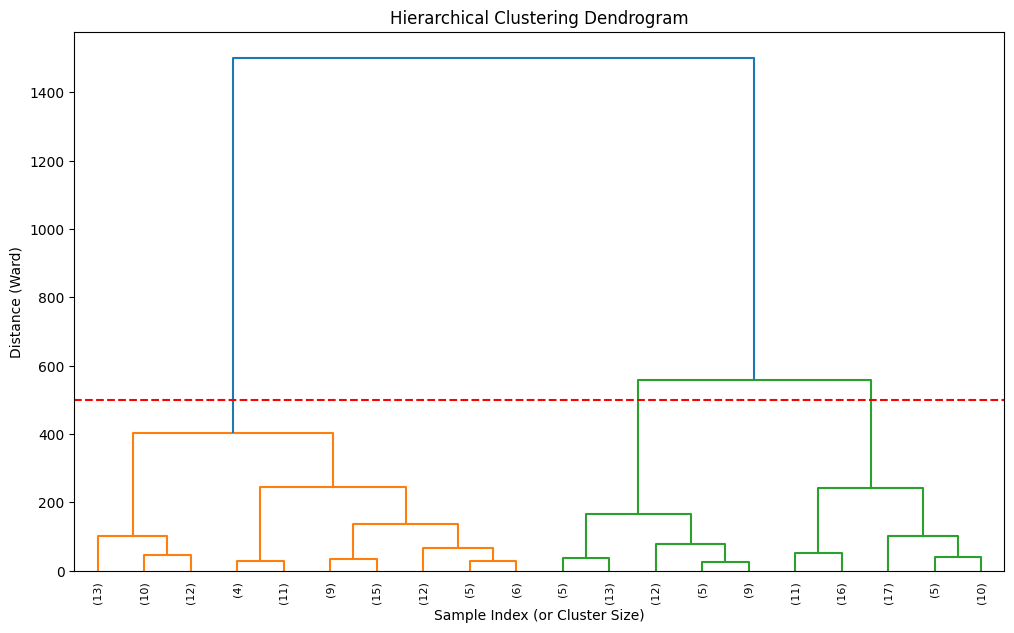

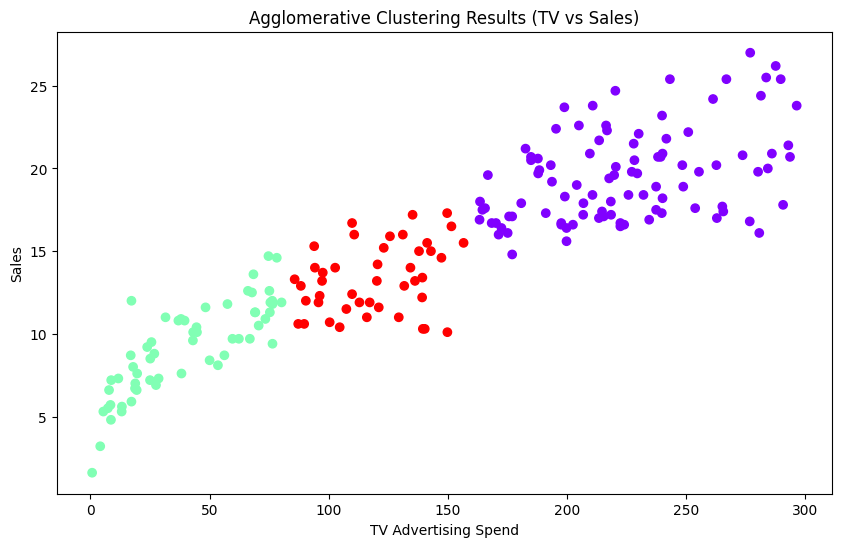

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 1. Load the Advertising Dataset
df = pd.read_csv('/content/advertising.csv')
# We'll use TV and Sales to visualize the clusters in 2D
X = df[['TV', 'Sales']].values

# 2. Generate the Linkage Matrix
# 'ward' minimizes the variance of clusters being merged
Z = linkage(X, method='ward')

# 3. Plot the Dendrogram
plt.figure(figsize=(12, 7))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index (or Cluster Size)")
plt.ylabel("Distance (Ward)")

dendrogram(
    Z,
    leaf_rotation=90.,  # rotates the x axis labels
    leaf_font_size=8.,  # font size for the x axis labels
    truncate_mode='lastp',  # show only the last p merged clusters
    p=20  # show only the last 20 merges for clarity
)
plt.axhline(y=500, color='r', linestyle='--') # Optional: Cut-off line
plt.show()

# 4. Fit the Agglomerative Model
# Based on the dendrogram, you can choose the number of clusters (e.g., n_clusters=3)
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = cluster.fit_predict(X)

# 5. Visualize the Clusters
plt.figure(figsize=(10, 6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow')
plt.title("Agglomerative Clustering Results (TV vs Sales)")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.show()